In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('C:/Users/Hp/Downloads/customer_shopping_behavior.csv')

In [8]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.747787,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.721856,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [8]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [10]:
# replace null value with meadin as per clothing category

df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [12]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [13]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [14]:
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [ ]:
#create new column age group
labels = ['Young adult','Adult','Middle-aged','Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

In [17]:
df[['age_group']].head(10)

,age_group
0,Middle-aged
1,Young adult
2,Middle-aged
3,Young adult
4,Middle-aged
5,Middle-aged
6,Senior
7,Young adult
8,Young adult
9,Middle-aged


In [ ]:
# Create a column purchace frequency days
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-weekly': 14,
    'Annually': 365,
    'Every 3 months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [19]:
df[['purchase_frequency_days','frequency_of_purchases']].head()

,purchase_frequency_days,frequency_of_purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually


In [20]:
(df['discount_applied']== df['promo_code_used']).all()

np.True_

In [21]:
df = df.drop('promo_code_used',axis=1)

In [22]:
import mysql.connector
dbcon = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="Ashlesha@24",
    database="customer_Behaviour_Analysis"
)

print("Connected!")

Connected!


In [12]:
pip install pandas sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Code for MySQL

In [48]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import pymysql

# ---- Step 1: Create the database first (if it doesn't already exist) ----
conn = pymysql.connect(host="localhost", user="root", password="Ashlesha@24", port=3306)
cursor = conn.cursor()
cursor.execute("CREATE DATABASE IF NOT EXISTS customer_Behaviour_Analysis")
conn.close()

# ---- Step 2: Create the SQLAlchemy engine ----
url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="Ashlesha@24",
    host="localhost",
    port=3306,
    database="customer_Behaviour_Analysis"
)
engine = create_engine(url)

# ---- Step 3: Load your data into a DataFrame ----
# Replace this with however you're actually loading your data
# Example if it's a CSV:
# df = pd.read_csv("your_file.csv")

# ---- Step 4: Push the DataFrame to MySQL ----
table_name = "customer"
df.to_sql(table_name, con=engine, if_exists="replace", index=False)

print("Data loaded successfully!")


Data loaded successfully!


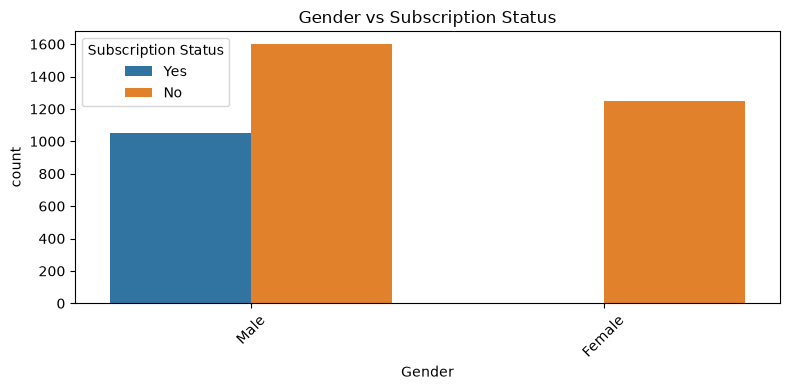

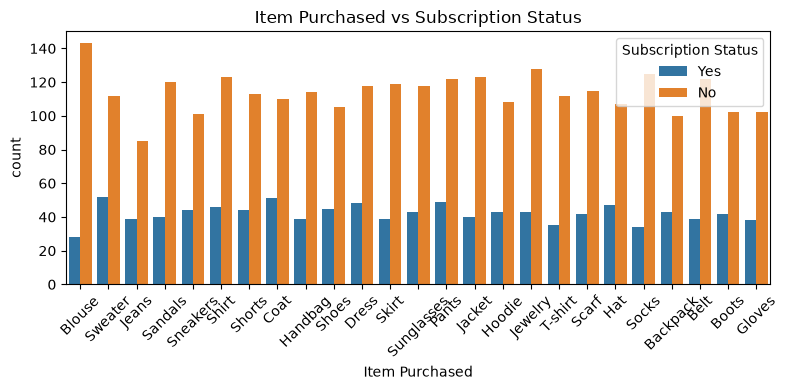

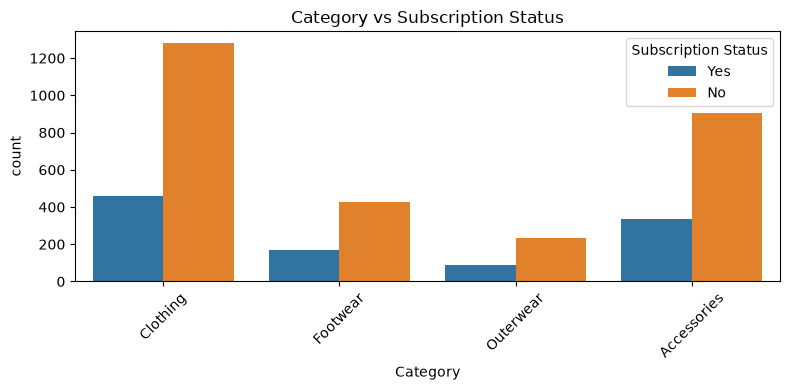

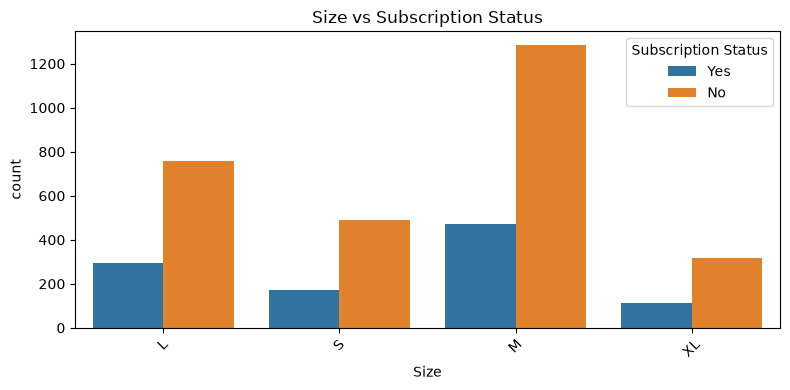

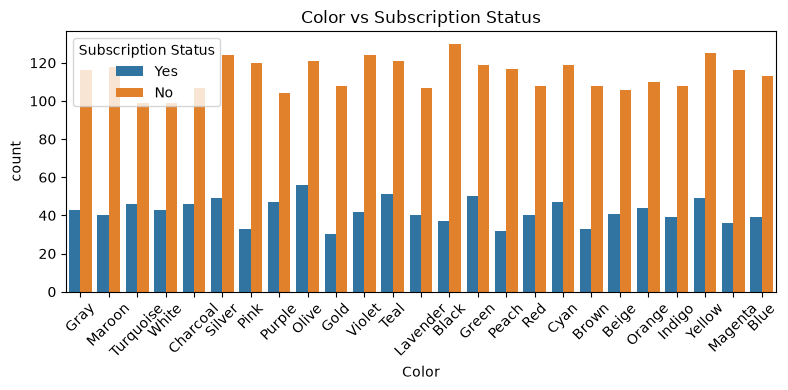

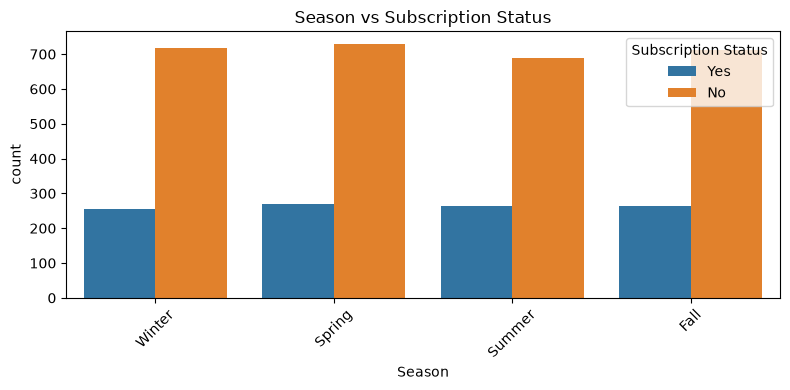

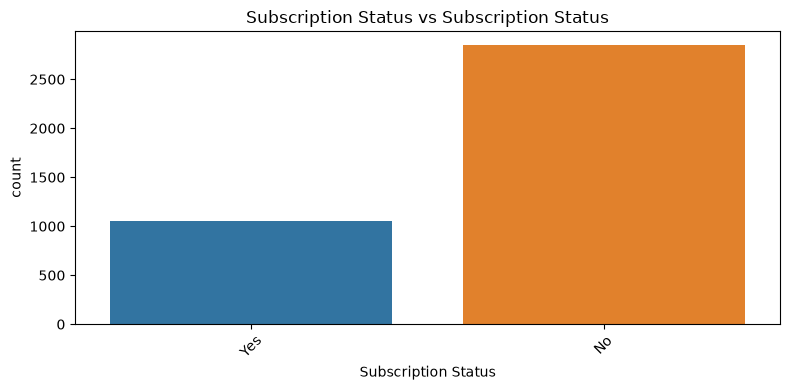

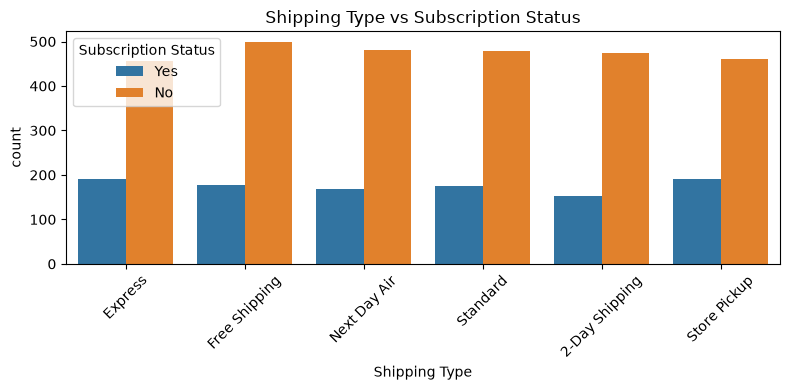

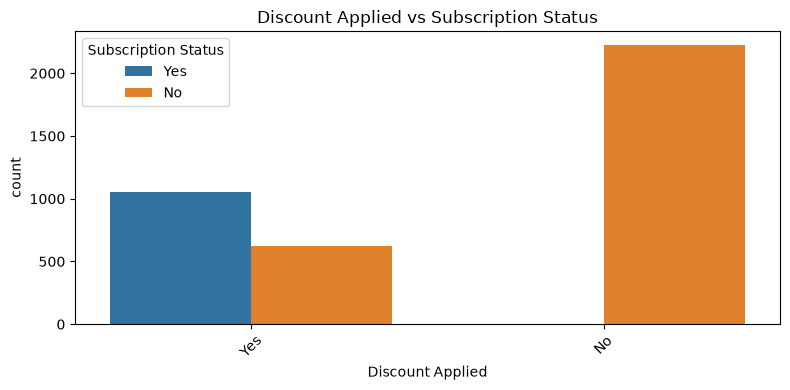

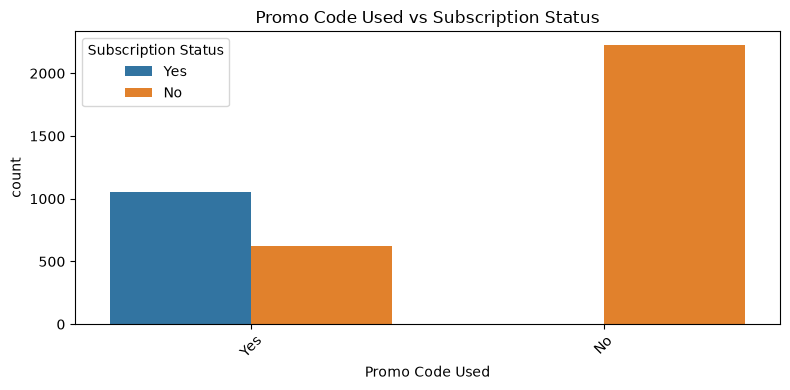

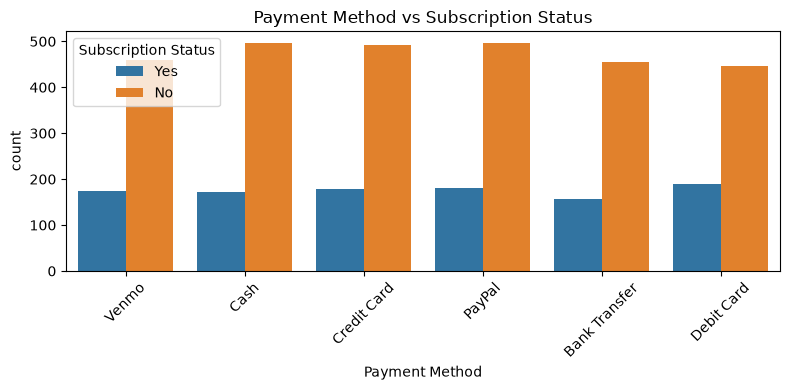

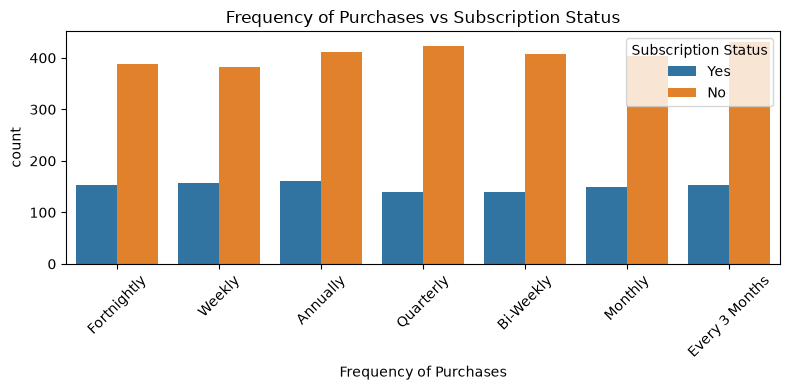

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define which columns are categorical (excluding numeric and ID columns)
categorical_feature = ['Gender', 'Item Purchased', 'Category', 'Size',
                        'Color', 'Season', 'Subscription Status', 'Shipping Type',
                        'Discount Applied', 'Promo Code Used', 'Payment Method',
                        'Frequency of Purchases']

for feature in categorical_feature:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=feature, hue='Subscription Status')
    plt.title(f'{feature} vs Subscription Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()